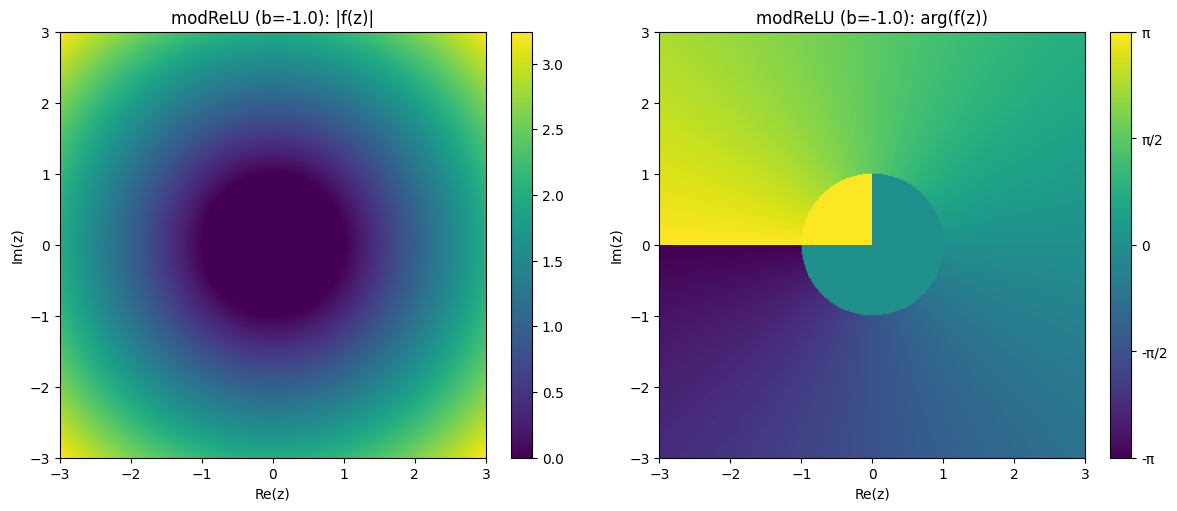

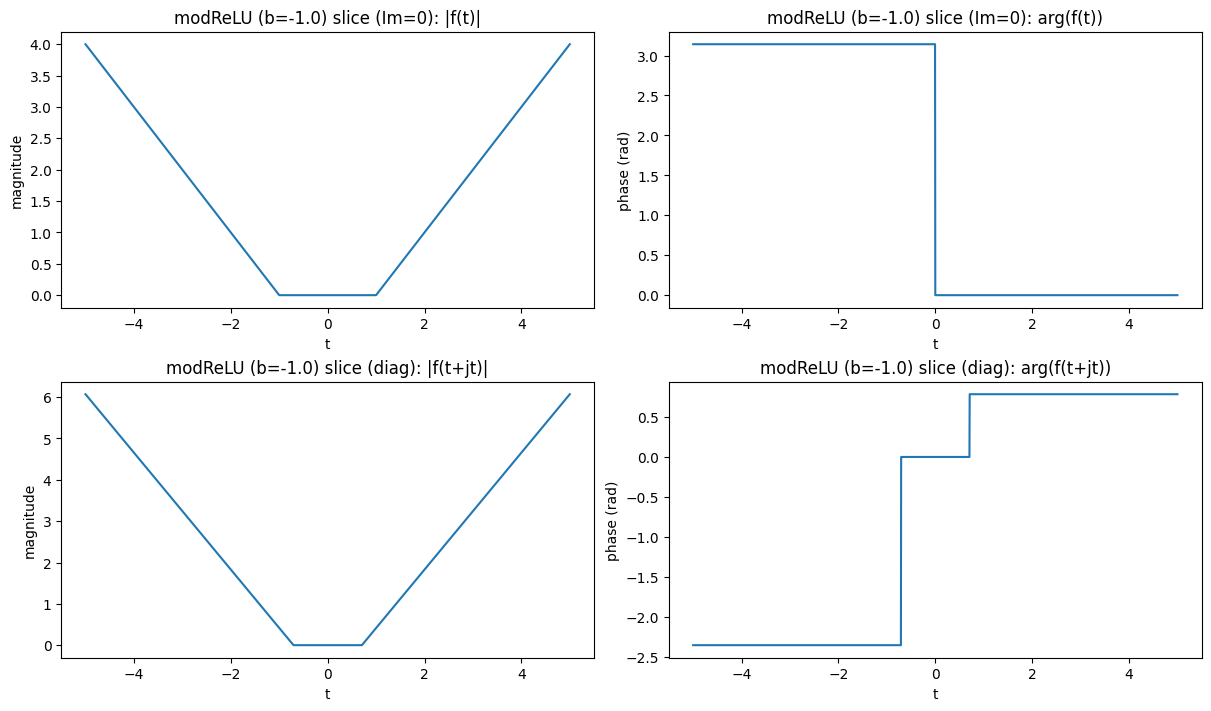

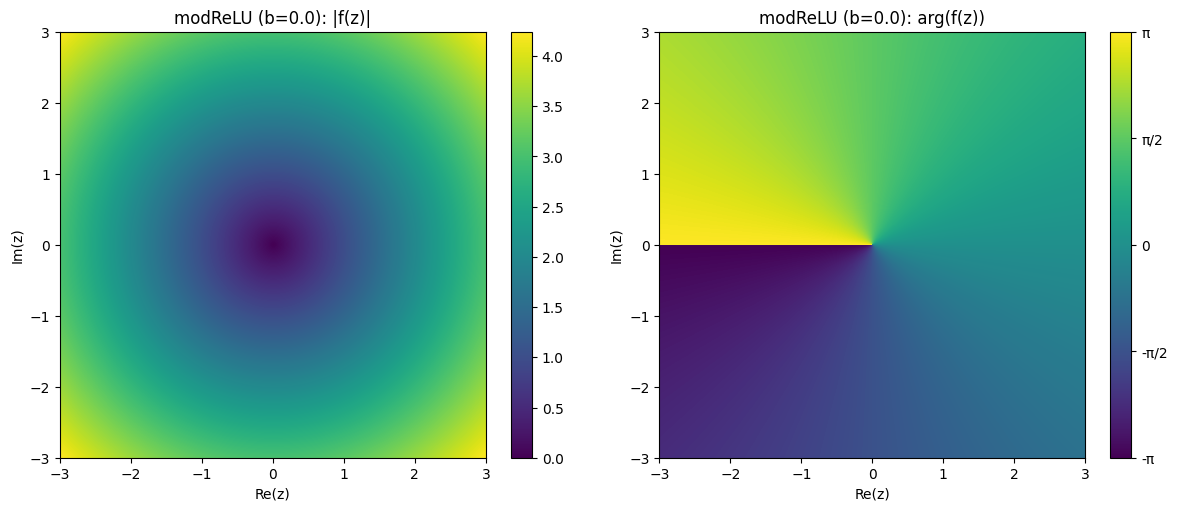

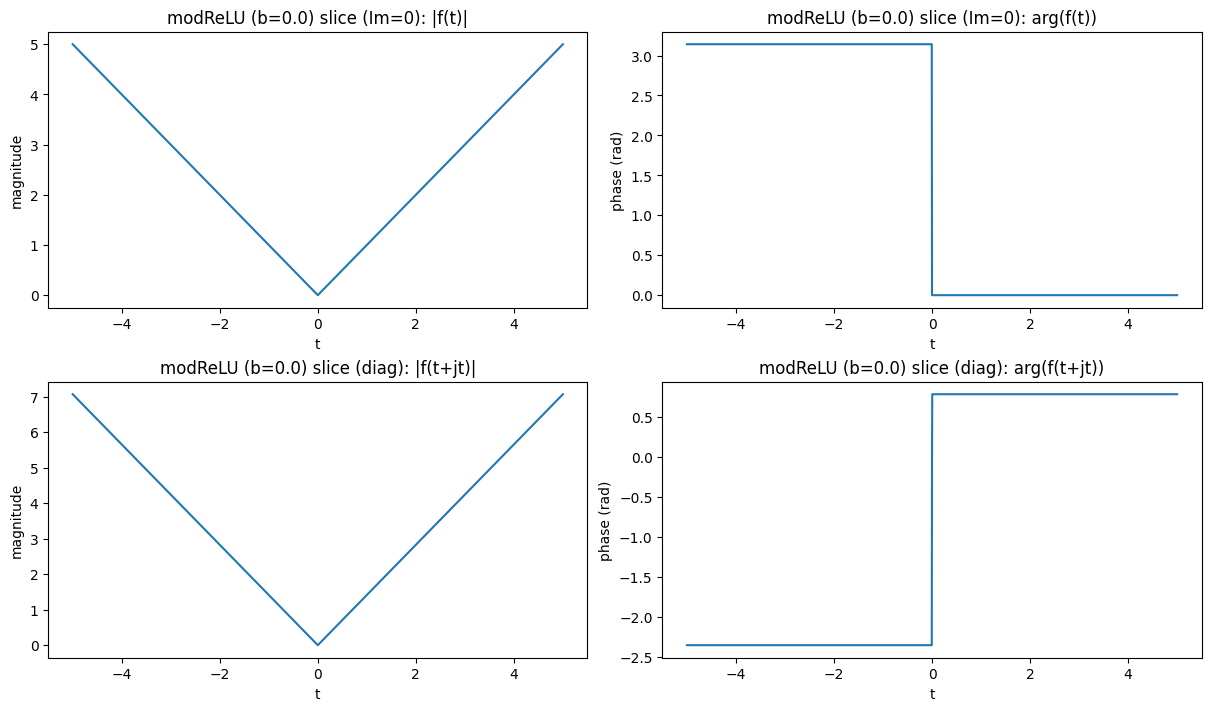

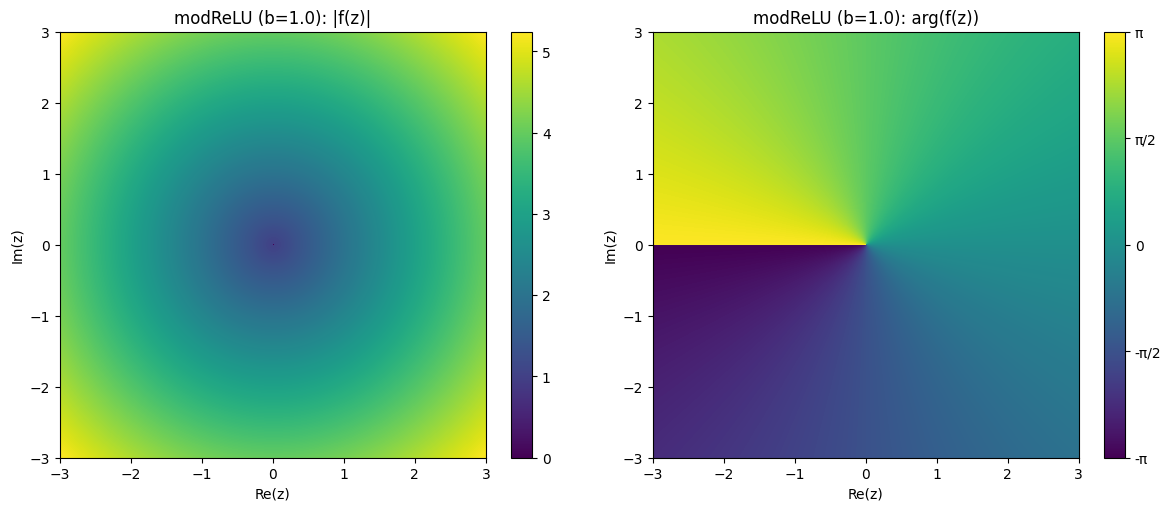

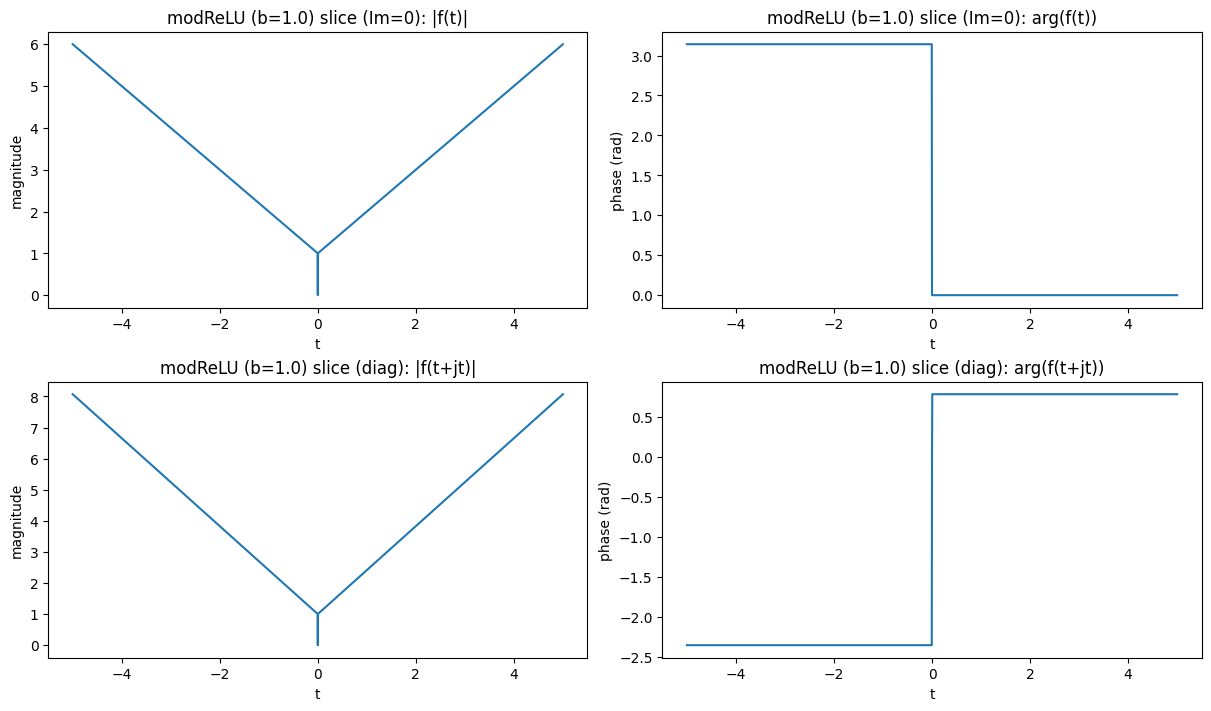

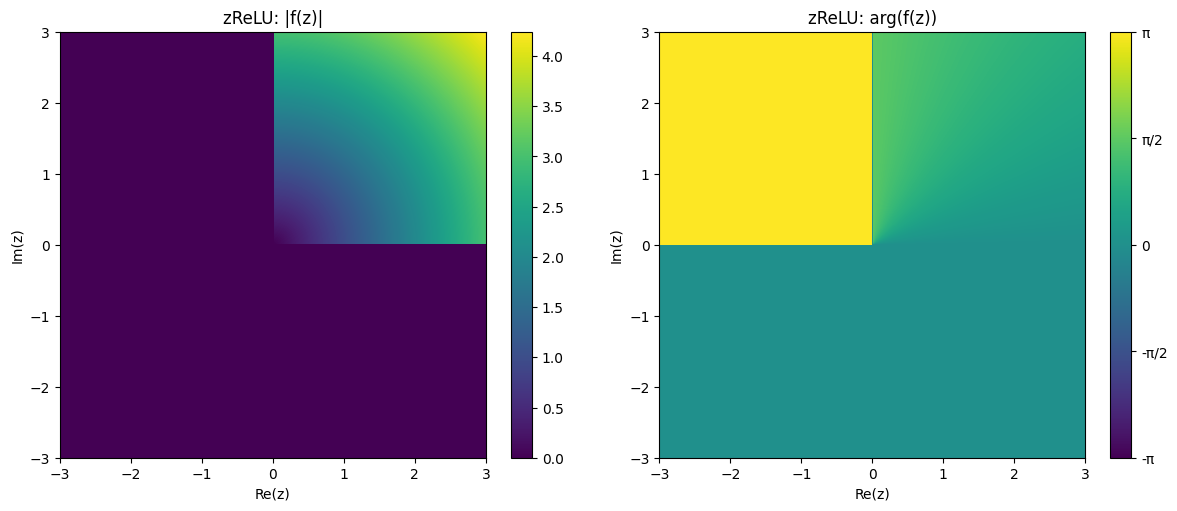

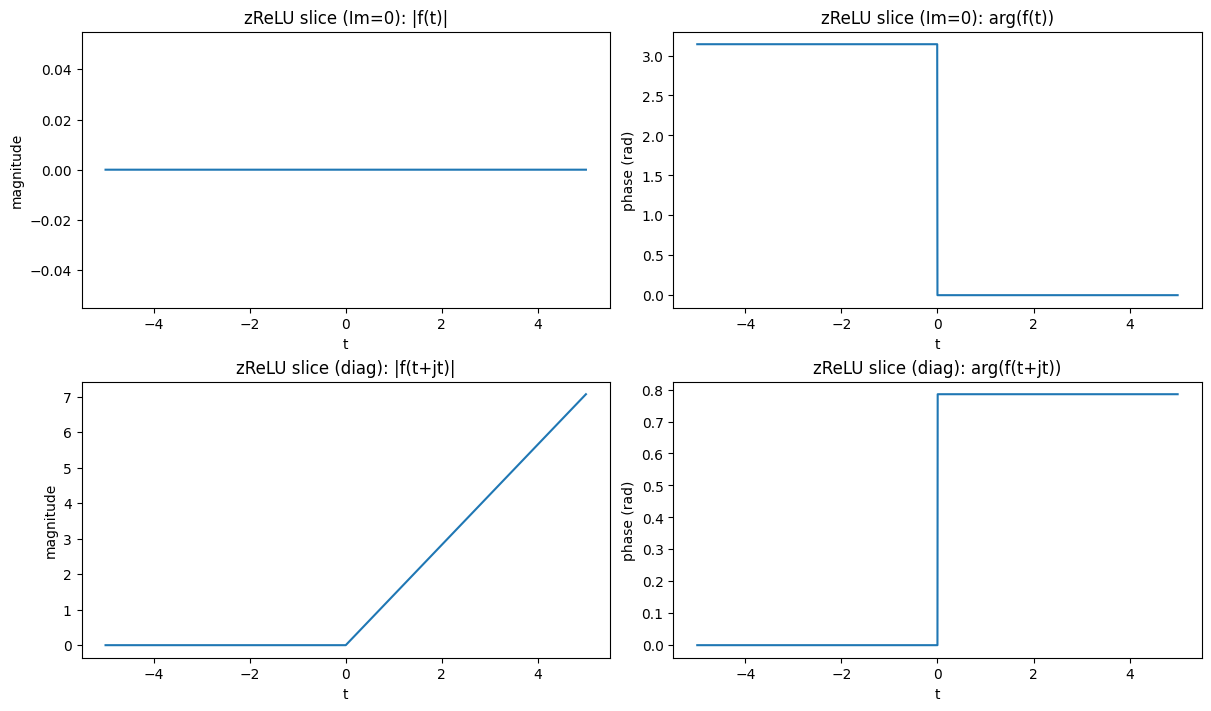

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# Complex activations
# ---------------------------
def modrelu(z, b=0.0, eps=1e-12):
    """
    modReLU for complex z:
      f(z) = ReLU(|z| + b) * z / (|z| + eps)
    b: bias (real scalar)
    """
    r = np.abs(z)
    scale = np.maximum(r + b, 0.0) / (r + eps)
    return scale * z

def zrelu(z):
    """
    zReLU:
      f(z) = z if Re(z)>0 and Im(z)>0 else 0
    (Keeps only the 1st quadrant)
    """
    mask = (z.real > 0) & (z.imag > 0)
    return z * mask

# ---------------------------
# Visualization helpers
# ---------------------------
def plot_activation_over_plane(act_fn, name, xlim=(-3,3), ylim=(-3,3), N=401, **kwargs):
    xs = np.linspace(xlim[0], xlim[1], N)
    ys = np.linspace(ylim[0], ylim[1], N)
    X, Y = np.meshgrid(xs, ys)
    Z = X + 1j * Y

    F = act_fn(Z, **kwargs) if kwargs else act_fn(Z)

    mag = np.abs(F)
    phase = np.angle(F)  # [-pi, pi]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

    im0 = axes[0].imshow(
        mag, origin="lower",
        extent=[xlim[0], xlim[1], ylim[0], ylim[1]],
        aspect="equal"
    )
    axes[0].set_title(f"{name}: |f(z)|")
    axes[0].set_xlabel("Re(z)")
    axes[0].set_ylabel("Im(z)")
    plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    im1 = axes[1].imshow(
        phase, origin="lower",
        extent=[xlim[0], xlim[1], ylim[0], ylim[1]],
        aspect="equal", vmin=-np.pi, vmax=np.pi
    )
    axes[1].set_title(f"{name}: arg(f(z))")
    axes[1].set_xlabel("Re(z)")
    axes[1].set_ylabel("Im(z)")
    cb = plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
    cb.set_ticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
    cb.set_ticklabels(["-π", "-π/2", "0", "π/2", "π"])

    plt.show()

def plot_slices(act_fn, name, tlim=(-5,5), M=2001, **kwargs):
    t = np.linspace(tlim[0], tlim[1], M)

    # Slice 1: real axis (z=t + 0j)
    z1 = t + 0j
    f1 = act_fn(z1, **kwargs) if kwargs else act_fn(z1)

    # Slice 2: diagonal (z=t + j t)
    z2 = t + 1j*t
    f2 = act_fn(z2, **kwargs) if kwargs else act_fn(z2)

    fig, axes = plt.subplots(2, 2, figsize=(12, 7), constrained_layout=True)

    axes[0,0].plot(t, np.abs(f1))
    axes[0,0].set_title(f"{name} slice (Im=0): |f(t)|")
    axes[0,0].set_xlabel("t")
    axes[0,0].set_ylabel("magnitude")

    axes[0,1].plot(t, np.angle(f1))
    axes[0,1].set_title(f"{name} slice (Im=0): arg(f(t))")
    axes[0,1].set_xlabel("t")
    axes[0,1].set_ylabel("phase (rad)")

    axes[1,0].plot(t, np.abs(f2))
    axes[1,0].set_title(f"{name} slice (diag): |f(t+jt)|")
    axes[1,0].set_xlabel("t")
    axes[1,0].set_ylabel("magnitude")

    axes[1,1].plot(t, np.angle(f2))
    axes[1,1].set_title(f"{name} slice (diag): arg(f(t+jt))")
    axes[1,1].set_xlabel("t")
    axes[1,1].set_ylabel("phase (rad)")

    plt.show()

# ---------------------------
# Run demos
# ---------------------------
# modReLU: try different b values to see the "dead zone" expand/shrink
for b in [-1.0, 0.0, 1.0]:
    plot_activation_over_plane(modrelu, f"modReLU (b={b})", N=401, b=b)
    plot_slices(modrelu, f"modReLU (b={b})", b=b)

# zReLU
plot_activation_over_plane(zrelu, "zReLU", N=401)
plot_slices(zrelu, "zReLU")